# Simple Linear Model (24h-Ahead Prediction)

**Strategy:**
- Use LINEAR REGRESSION (simplest model)
- Features: Annual patterns (1-4 years ago) + Weekly patterns (2-7 days ago)
- Compare with baseline (4-year average)

**Features:**
1. Annual lags: 1yr, 2yr, 3yr, 4yr ago (same day/hour last year)
2. Weekly lags: 3d, 4d, 5d, 6d, 7d, 8d, 9d ago (recent days)

**Total: 11 lag features only (no time features, no weather)**

In [23]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
print("✓ Libraries loaded")

✓ Libraries loaded


## Configuration

In [24]:
# Features: Annual + Weekly lags only
ANNUAL_LAGS = ['mw_bf_lag_1yr', 'mw_bf_lag_2yr', 'mw_bf_lag_3yr', 'mw_bf_lag_4yr']  # 1yr, 2yr, 3yr, 4yr
WEEKLY_LAGS = ['mw_lag_72h', 'mw_lag_96h', 'mw_lag_120h', 'mw_lag_144h', 'mw_lag_168h', 'mw_lag_192h', 'mw_lag_216h']  # 3d-9d

ALL_FEATURES = ANNUAL_LAGS + WEEKLY_LAGS

HORIZON = 24  # Predict 24 hours ahead

# Year-based CV windows
CV_WINDOWS = [
    {'train_years': [2016, 2017, 2018, 2019], 'test_year': 2020},
    {'train_years': [2017, 2018, 2019, 2020], 'test_year': 2021},
    {'train_years': [2018, 2019, 2020, 2021], 'test_year': 2022},
    {'train_years': [2019, 2020, 2021, 2022], 'test_year': 2023},
    {'train_years': [2020, 2021, 2022, 2023], 'test_year': 2024}
]

print(f"Configuration:")
print(f"  Model: Linear Regression")
print(f"  Prediction horizon: {HORIZON}h ahead")
print(f"  Annual lags (1-4 years): {ANNUAL_LAGS}")
print(f"  Weekly lags (2-7 days): {WEEKLY_LAGS}")
print(f"  Total features: {len(ALL_FEATURES)}")
print(f"  CV folds: {len(CV_WINDOWS)} (year-based)")

Configuration:
  Model: Linear Regression
  Prediction horizon: 24h ahead
  Annual lags (1-4 years): ['mw_bf_lag_1yr', 'mw_bf_lag_2yr', 'mw_bf_lag_3yr', 'mw_bf_lag_4yr']
  Weekly lags (2-7 days): ['mw_lag_72h', 'mw_lag_96h', 'mw_lag_120h', 'mw_lag_144h', 'mw_lag_168h', 'mw_lag_192h', 'mw_lag_216h']
  Total features: 11
  CV folds: 5 (year-based)


## Load Data

In [25]:
print("="*80)
print("Loading Data")
print("="*80)

# Load
df = pd.read_parquet('../dataset/preprocessed/full_year_features.parquet')
df['datetime_beginning_ept'] = pd.to_datetime(df['datetime_beginning_ept'])

# Filter BF period
bf_df = df[(df['days_from_bf'] >= -9) & (df['days_from_bf'] <= 0)].copy()
bf_df = bf_df.sort_values(['load_area', 'datetime_beginning_ept']).reset_index(drop=True)

# Create target: 24h ahead
bf_df['target_24h'] = bf_df.groupby('load_area')['mw'].shift(-24)
bf_df = bf_df.dropna(subset=['target_24h'])

print(f"BF period data: {len(bf_df):,} rows")
print(f"Years: {sorted(bf_df['year'].unique())}")

# Check feature availability
available_features = [f for f in ALL_FEATURES if f in bf_df.columns]
missing_features = [f for f in ALL_FEATURES if f not in bf_df.columns]

print(f"\nFeature availability:")
print(f"  Available: {len(available_features)}/{len(ALL_FEATURES)}")
if missing_features:
    print(f"  Missing: {missing_features}")

# Use only available features
FEATURES = available_features
print(f"\nUsing {len(FEATURES)} features: {FEATURES}")

Loading Data
BF period data: 63,096 rows
Years: [np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024)]

Feature availability:
  Available: 11/11

Using 11 features: ['mw_bf_lag_1yr', 'mw_bf_lag_2yr', 'mw_bf_lag_3yr', 'mw_bf_lag_4yr', 'mw_lag_72h', 'mw_lag_96h', 'mw_lag_120h', 'mw_lag_144h', 'mw_lag_168h', 'mw_lag_192h', 'mw_lag_216h']


## Calculate Baseline (4-Year Average)

In [26]:
print("="*80)
print("Calculating Baseline (4-Year Average)")
print("="*80)

# Get load areas (exclude RTO)
load_areas = sorted([a for a in bf_df['load_area'].unique() if a != 'RTO'])

baseline_results = []

for area in load_areas:
    area_data = bf_df[bf_df['load_area'] == area].copy()
    
    area_rmses = []
    
    for window in CV_WINDOWS:
        train_data = area_data[area_data['year'].isin(window['train_years'])]
        test_data = area_data[area_data['year'] == window['test_year']]
        
        if len(test_data) == 0:
            continue
        
        # Baseline: average of training years
        baseline_pred = train_data['mw'].mean()
        
        # Evaluate
        y_true = test_data['target_24h']
        y_pred = np.full(len(y_true), baseline_pred)
        
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        area_rmses.append(rmse)
    
    if area_rmses:
        baseline_results.append({
            'area': area,
            'baseline_rmse': np.mean(area_rmses)
        })

baseline_df = pd.DataFrame(baseline_results)

print(f"\n✓ Baseline calculated for {len(baseline_df)} areas")
print(f"Average baseline RMSE: {baseline_df['baseline_rmse'].mean():.2f}")

Calculating Baseline (4-Year Average)

✓ Baseline calculated for 29 areas
Average baseline RMSE: 359.81


## Train Linear Regression Model

In [27]:
print("="*80)
print("Training Linear Regression Model")
print("="*80)
print(f"Model: Simple Linear Regression (no regularization)")
print(f"Features: {len(FEATURES)} lag features only")

model_results = []

for area in load_areas:
    area_data = bf_df[bf_df['load_area'] == area].copy()
    
    area_rmses = []
    area_coefficients = []
    
    for window in CV_WINDOWS:
        train_mask = area_data['year'].isin(window['train_years'])
        test_mask = area_data['year'] == window['test_year']
        
        # Prepare data
        X_train = area_data.loc[train_mask, FEATURES]
        y_train = area_data.loc[train_mask, 'target_24h']
        X_test = area_data.loc[test_mask, FEATURES]
        y_test = area_data.loc[test_mask, 'target_24h']
        
        # Drop rows with NaN in features
        train_valid = X_train.notna().all(axis=1)
        test_valid = X_test.notna().all(axis=1)
        
        X_train_clean = X_train[train_valid]
        y_train_clean = y_train[train_valid]
        X_test_clean = X_test[test_valid]
        y_test_clean = y_test[test_valid]
        
        if len(X_test_clean) == 0 or len(X_train_clean) == 0:
            continue
        
        # Train linear regression
        model = LinearRegression()
        model.fit(X_train_clean, y_train_clean)
        
        # Predict
        y_pred = model.predict(X_test_clean)
        rmse = np.sqrt(mean_squared_error(y_test_clean, y_pred))
        area_rmses.append(rmse)
        
        # Store coefficients
        area_coefficients.append(model.coef_)
    
    if area_rmses:
        avg_coef = np.mean(area_coefficients, axis=0)
        model_results.append({
            'area': area,
            'model_rmse': np.mean(area_rmses),
            'coefficients': avg_coef
        })

model_df = pd.DataFrame(model_results)

print(f"\n✓ Linear model trained for {len(model_df)} areas")
print(f"Average model RMSE: {model_df['model_rmse'].mean():.2f}")

Training Linear Regression Model
Model: Simple Linear Regression (no regularization)
Features: 11 lag features only

✓ Linear model trained for 29 areas
Average model RMSE: 363.44


## Compare Baseline vs Linear Model

In [28]:
# Merge results
comparison_df = baseline_df.merge(model_df, on='area')
comparison_df['improvement_%'] = ((comparison_df['baseline_rmse'] - comparison_df['model_rmse']) / comparison_df['baseline_rmse']) * 100
comparison_df = comparison_df.sort_values('improvement_%', ascending=False)

print("="*80)
print("BASELINE vs LINEAR MODEL COMPARISON")
print("="*80)
print(comparison_df[['area', 'baseline_rmse', 'model_rmse', 'improvement_%']].to_string(index=False))

print(f"\n" + "="*80)
print("SUMMARY")
print("="*80)
print(f"Average Baseline RMSE: {comparison_df['baseline_rmse'].mean():,.2f}")
print(f"Average Model RMSE:    {comparison_df['model_rmse'].mean():,.2f}")
print(f"Average Improvement:   {comparison_df['improvement_%'].mean():.2f}%")

# Count areas with improvement
improved = (comparison_df['improvement_%'] > 0).sum()
total = len(comparison_df)
print(f"\nAreas improved: {improved}/{total} ({improved/total*100:.1f}%)")

BASELINE vs LINEAR MODEL COMPARISON
  area  baseline_rmse  model_rmse  improvement_%
  RECO      17.848725   10.774402      39.634894
    JC     290.098460  208.688867      28.062746
  AECO     123.062221   90.151769      26.742937
  VMEU       9.386527    6.951132      25.945644
 PEPCO     333.523503  270.032998      19.036291
    PE     482.835292  411.934094      14.684345
    PS     481.090778  410.499702      14.673130
  DEOK     322.771011  306.388132       5.075697
   UGI      16.670100   15.986893       4.098397
 PAPWR      75.473216   72.961010       3.328605
    CE    1136.531666 1099.125658       3.291242
   DOM    1683.159872 1635.832117       2.811840
    BC     406.233912  395.262106       2.700859
    PN     237.164761  231.259031       2.490138
    ME     223.649887  224.886585      -0.552961
   DUQ     142.707209  144.619023      -1.339676
EASTON       4.389762    4.523428      -3.044956
AEPIMP     304.811464  316.779945      -3.926520
    OE     713.740714  742.195799

## Visualization

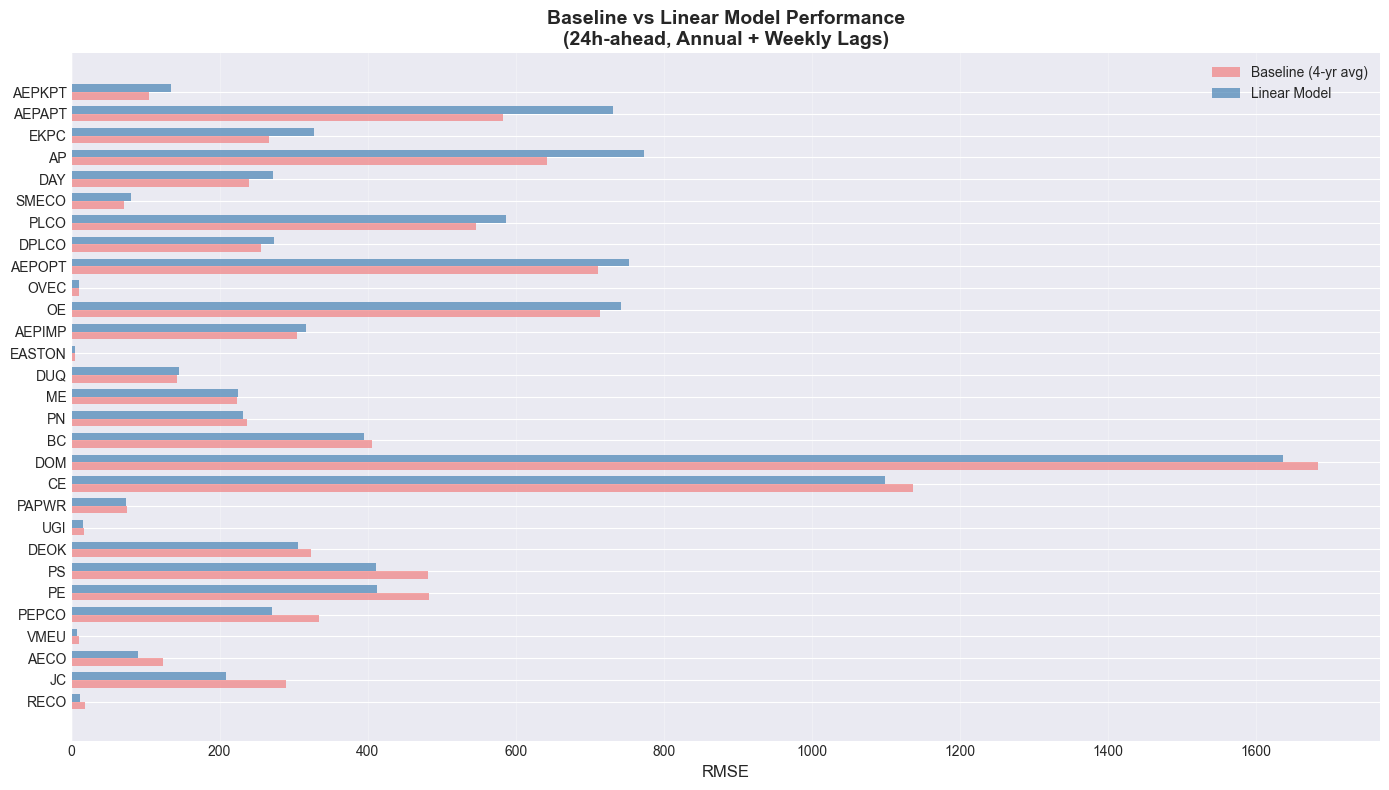

In [29]:
# Baseline vs Model comparison
fig, ax = plt.subplots(figsize=(14, 8))

x = np.arange(len(comparison_df))
width = 0.35

ax.barh(x - width/2, comparison_df['baseline_rmse'], width, label='Baseline (4-yr avg)', alpha=0.7, color='lightcoral')
ax.barh(x + width/2, comparison_df['model_rmse'], width, label='Linear Model', alpha=0.7, color='steelblue')

ax.set_yticks(x)
ax.set_yticklabels(comparison_df['area'])
ax.set_xlabel('RMSE', fontsize=12)
ax.set_title('Baseline vs Linear Model Performance\n(24h-ahead, Annual + Weekly Lags)', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

## Feature Coefficients Analysis

## All Areas Beta Coefficients

Show beta coefficients for all areas

In [30]:
print("="*80)
print("LINEAR REGRESSION COEFFICIENTS (BETA VALUES) FOR ALL AREAS")
print("="*80)

# Create dataframe with all coefficients
all_coef_data = []
for idx, row in model_df.iterrows():
    area = row['area']
    coefs = row['coefficients']
    
    coef_dict = {'area': area}
    for i, feat in enumerate(FEATURES):
        coef_dict[feat] = coefs[i]
    
    all_coef_data.append(coef_dict)

all_coef_df = pd.DataFrame(all_coef_data)

# Display
print("\nCoefficients by area:")
print(all_coef_df.to_string(index=False))

# Summary statistics
print(f"\n{'='*80}")
print("COEFFICIENT STATISTICS ACROSS ALL AREAS")
print("="*80)
for feat in FEATURES:
    mean_coef = all_coef_df[feat].mean()
    std_coef = all_coef_df[feat].std()
    min_coef = all_coef_df[feat].min()
    max_coef = all_coef_df[feat].max()
    
    print(f"\n{feat}:")
    print(f"  Mean: {mean_coef:>8.4f}")
    print(f"  Std:  {std_coef:>8.4f}")
    print(f"  Min:  {min_coef:>8.4f}")
    print(f"  Max:  {max_coef:>8.4f}")

# Save to CSV
all_coef_df.to_csv('../dataset/preprocessed/linear_model_coefficients.csv', index=False)
print(f"\n✓ Coefficients saved to: ../dataset/preprocessed/linear_model_coefficients.csv")

LINEAR REGRESSION COEFFICIENTS (BETA VALUES) FOR ALL AREAS

Coefficients by area:
  area  mw_bf_lag_1yr  mw_bf_lag_2yr  mw_bf_lag_3yr  mw_bf_lag_4yr  mw_lag_72h  mw_lag_96h  mw_lag_120h  mw_lag_144h  mw_lag_168h  mw_lag_192h  mw_lag_216h
  AECO      -0.027361       0.257405      -0.137967      -0.019059    0.295167    0.020878     0.021157     0.325713     0.122592     0.082704     0.027050
AEPAPT       0.178200      -0.099503       0.392925       0.250856    0.299615   -0.012815    -0.128496     0.026057    -0.112869    -0.159249    -0.020224
AEPIMP      -0.077662      -0.060069       0.129892       0.268679    0.342675    0.360373     0.290409     0.213027    -0.011556    -0.341636    -0.322516
AEPKPT      -0.003314       0.068380       0.256358       0.287050    0.326117    0.156334     0.116269    -0.203555    -0.137979    -0.054730    -0.349662
AEPOPT      -0.119680       0.107594       0.107222       0.138676    0.337010    0.470375     0.001158     0.325062    -0.050885    -0.28

Linear Regression Coefficients (AECO)
     feature  coefficient
  mw_lag_72h     0.408851
 mw_lag_168h     0.228958
mw_lag_8760h     0.181833


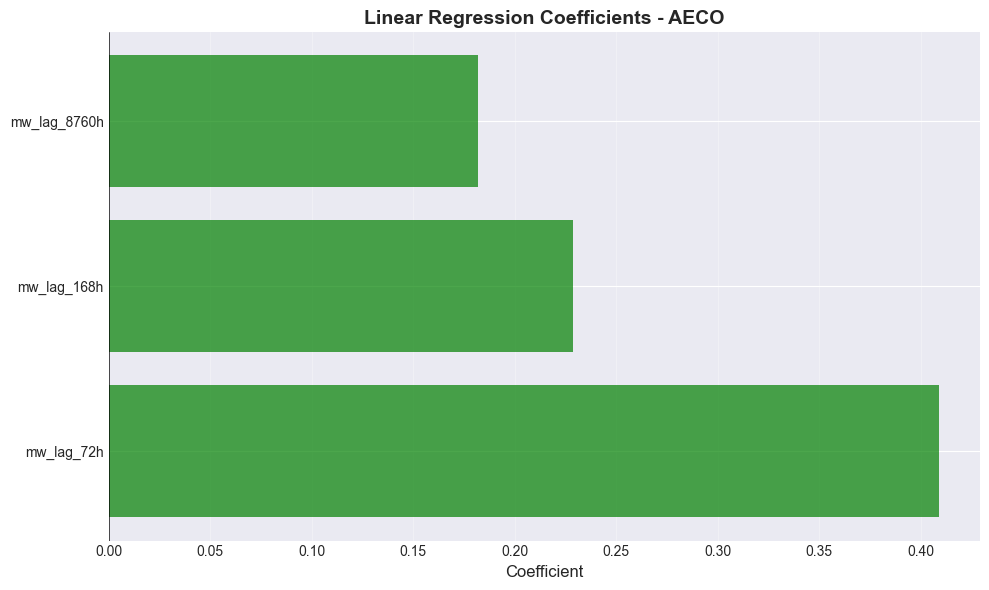

In [19]:
# Analyze coefficients for a sample area
sample_area = 'AECO' if 'AECO' in model_df['area'].values else model_df['area'].iloc[0]
sample_coef = model_df[model_df['area'] == sample_area]['coefficients'].iloc[0]

coef_df = pd.DataFrame({
    'feature': FEATURES,
    'coefficient': sample_coef
}).sort_values('coefficient', key=abs, ascending=False)

print("="*80)
print(f"Linear Regression Coefficients ({sample_area})")
print("="*80)
print(coef_df.to_string(index=False))

# Plot coefficients
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['green' if c > 0 else 'red' for c in coef_df['coefficient']]
ax.barh(range(len(coef_df)), coef_df['coefficient'], alpha=0.7, color=colors)
ax.set_yticks(range(len(coef_df)))
ax.set_yticklabels(coef_df['feature'])
ax.set_xlabel('Coefficient', fontsize=12)
ax.set_title(f'Linear Regression Coefficients - {sample_area}', fontsize=14, fontweight='bold')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()